In [1]:
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import Dataset

DATA_PATH = Path("../data")

folders = [directory for directory in DATA_PATH.iterdir() if directory.is_dir()]

sensfloor_readout_df = pd.read_csv("../datasensfloor_usb_readout_2025-11-27_124229.csv", sep=";")

Positions : [[4 1]
 [2 1]
 [3 1]]
Signals: [[129 130 127 126 127 127 127 127]
 [127 127 129 129 166 141 129 130]
 [127 130 128 131 144 129 128 127]]


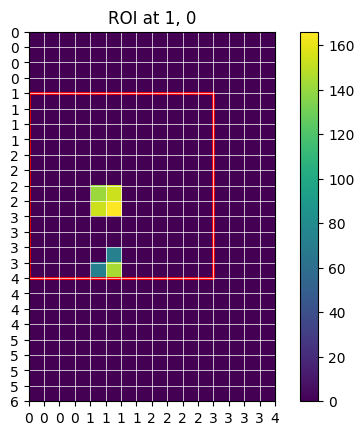

In [54]:
from floor_handler import FloorHandler

floor_handler = FloorHandler(x_size=6, y_size=4, history_len=10, kernel_size=3)

last_frame_number = sensfloor_readout_df["frame_number"].max()
rois = {}

FRAME_NUMBER = 378

messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == FRAME_NUMBER]
signals = messages[["0", "1", "2", "3", "4", "5", "6", "7"]].to_numpy()
positions = messages[["x", "y"]].to_numpy() - 1

print(f"Positions : {positions}")
print(f"Signals: {signals}")

floor_handler.update_floor(signals=signals, positions=positions)
rois[f"{FRAME_NUMBER}"] = floor_handler.get_roi()


floor_handler.draw()

In [55]:
floor_handler = FloorHandler(x_size=6, y_size=4, history_len=10, kernel_size=3)

last_frame_number = sensfloor_readout_df["frame_number"].max()
rois = {}

for frame_number in range(last_frame_number):
    messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == frame_number]
    signals = messages[["0", "1", "2", "3", "4", "5", "6", "7"]].to_numpy()
    positions = messages[["x", "y"]].to_numpy() - 1
    floor_handler.update_floor(signals=signals, positions=positions)
    rois[f"{frame_number}"] = floor_handler.get_roi()


In [ ]:
frame_numbers = sensfloor_readout_df.groupby("frame_number").mean().index.tolist()


for frame_number in frame_numbers:
    messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == frame_number]
    break

messages

,timestamp,frame_number,group_id,magic_number,x,y,0,1,2,3,4,5,6,7
0,1439811708,0,23,10,2,1,150,179,138,126,126,126,131,227
1,1439838500,0,23,10,1,2,144,147,135,126,129,138,129,128
2,1439846958,0,23,10,2,1,149,181,138,127,126,126,130,242
3,1439853667,0,23,10,2,1,148,172,132,127,126,127,130,244
4,1439859583,0,23,10,2,1,149,192,134,127,126,126,130,255
5,1439865542,0,23,10,1,2,143,147,136,126,126,132,127,125
6,1439871292,0,23,10,2,2,128,128,127,130,137,130,128,128
7,1439879042,0,23,10,1,2,141,146,137,126,126,132,127,126
8,1439884750,0,23,10,2,1,164,246,135,127,126,127,129,241
9,1439890125,0,23,10,2,2,127,128,128,139,150,129,128,128
